In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install python_speech_features

  Preparing metadata (setup.py) ... done
  Created wheel for python_speech_features: filename=python_speech_features-0.6-py3-none-any.whl size=5870 sha256=ef3b9a19b6a098263930c1ae763d3f214b01d56c2e575e6906e10c851b18d7c1
  Stored in directory: /root/.cache/pip/wheels/5a/9e/68/30bad9462b3926c29e315df16b562216d12bdc215f4d240294
Successfully built python_speech_features


In [4]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import librosa

from pip._internal import main as pip
#try:
from python_speech_features import mfcc, logfbank

/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [6]:
# Noise reduction
def envelope(y, rate, threshold):
     mask = []
     y = pd.Series(y).apply(np.abs)
     y_mean = y.rolling(window=int(rate/10), min_periods=1, center=True).mean()
     for mean in y_mean:
         if mean > threshold:
             mask.append(True)
         else:
             mask.append(False) # was: mask.append=False (very unlikely to be right)
     return mask

In [7]:
def calc_fft(y, rate):
    n=len(y)
    freq = np.fft.rfftfreq(n, d=1/rate)
    Y = abs(np.fft.rfft(y)/n) # to normalize the signal which is in different length
    return(Y, freq)

In [8]:
dir_path ='/content/drive/MyDrive/final_project/second_draft'

In [9]:
df = pd.read_csv(dir_path + '/train_info.csv')
#df_new.to_csv(dir_path + '/test_info.csv')
df.head()


,Unnamed: 0,fname,label,length,participant
0,0,1.0_vfy_p_2_list_1_35.wav,vfy,1.690930,p_2
1,1,1.6_vfy_p_4_list_4_33.wav,vfy,1.525986,p_4
2,2,0.4_vfy_p_4_list_4_27.wav,vfy,1.203401,p_4
3,3,1.0_vfy_p_2_list_1_8.wav,vfy,2.258322,p_2
4,4,1.6_vfy_p_6_list_3_2.wav,vfy,1.448707,p_6


In [10]:
df.set_index("fname", inplace = True)
df.head(2)

,Unnamed: 0,label,length,participant
fname,,,,
1.0_vfy_p_2_list_1_35.wav,0,vfy,1.690930,p_2
1.6_vfy_p_4_list_4_33.wav,1,vfy,1.525986,p_4


In [11]:
for f in df.index:
    rate, signal = wavfile.read(dir_path + "/train_full/"+f)
    df.at[f, "length"] = signal.shape[0]/rate # "at" will allow us to reach individual classes



In [12]:
df.head()

,Unnamed: 0,label,length,participant
fname,,,,
1.0_vfy_p_2_list_1_35.wav,0,vfy,1.690930,p_2
1.6_vfy_p_4_list_4_33.wav,1,vfy,1.525986,p_4
0.4_vfy_p_4_list_4_27.wav,2,vfy,1.203401,p_4
1.0_vfy_p_2_list_1_8.wav,3,vfy,2.258322,p_2
1.6_vfy_p_6_list_3_2.wav,4,vfy,1.448707,p_6


In [13]:
classes = list(np.unique(df.label))
class_dist =df.groupby(["label"])["length"].mean() # length in double [] creates problem in the pie chart
class_dist.head()

label
normal    1.365883
vfy       1.476461
Name: length, dtype: float64

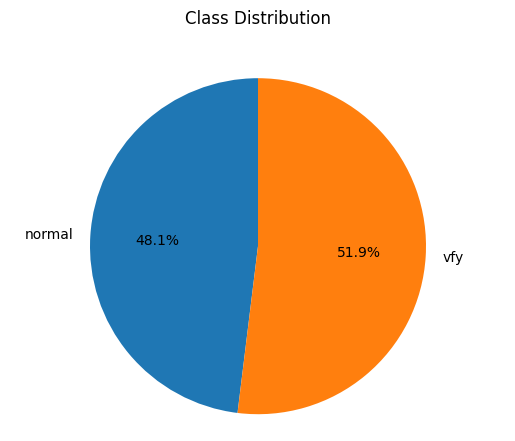

In [14]:
fig, ax = plt.subplots()
ax.set_title("Class Distribution", y=1.08)
ax.pie(class_dist, labels=class_dist.index, autopct="%1.1f%%",
       shadow= False, startangle=90)
ax.axis("equal")
plt.show()
df.reset_index(inplace=True)

In [15]:
signals = {}
fft = {}
fbank = {}
mfccs = {}

for c in classes:
    #print(c)
    wav_file=df[df.label == c].iloc[0,0]
    signal, rate = librosa.load(dir_path + "/train_full/"+wav_file, sr=22050)
    mask = envelope(signal, rate, 0.0005)
    signal = signal[mask]
    signals[c] = signal
    fft[c]=calc_fft(signal, rate)

    # nfft=1second/40 is 0.025 is eaqual to window length so 44100/40 is 1102.5. For me it should be 22050/40
    bank = logfbank(signal[:rate], rate, nfilt=26, nfft=551).T
    fbank[c]=bank
    mel=mfcc(signal[:rate],rate,numcep=13, nfilt=26, nfft=551).T #numcep=nfilt/2
    mfccs[c]=mel

In [ ]:
path = "/content/drive/MyDrive/final_project/second_draft/"

# To clean date and save in the new folders that we created.
if len(os.listdir(path + "test_clean"))==0:
    for f in tqdm(df.fname):
        signal, rate = librosa.load(path + "test_full/"+f, sr=16000)
        mask = envelope(signal,rate, 0.0005)
        wavfile.write(filename=path + "test_clean/"+f, rate=rate, data=signal[mask])

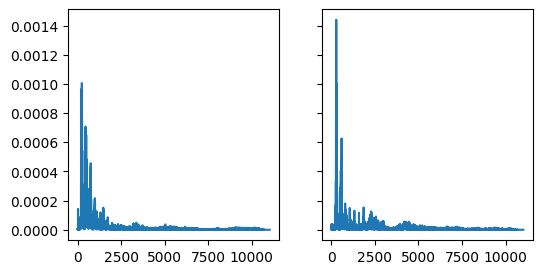

In [16]:

fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(6,3))
ax1, ax2 = ax
ax1Y, ax1freq = fft["normal"][0], fft["normal"][1]
ax1.plot(ax1freq, ax1Y)
ax2Y, ax2freq = fft["vfy"][0], fft["vfy"][1]
ax2.plot(ax2freq, ax2Y)
plt.savefig("/content/drive/MyDrive/final_project/second_draft/plot/fft");

In [17]:
def plot_mfccs(mfccs):
    fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Mel Frequency Cepstrum Coefficients', size=16)
    i = 0
    for y in range(5):
        axes[y].set_title(list(mfccs.keys())[i])
        axes[y].imshow(list(mfccs.values())[i],
                    cmap='hot', interpolation='nearest')
        axes[y].get_xaxis().set_visible(False)
        axes[y].get_yaxis().set_visible(False)
        i += 1

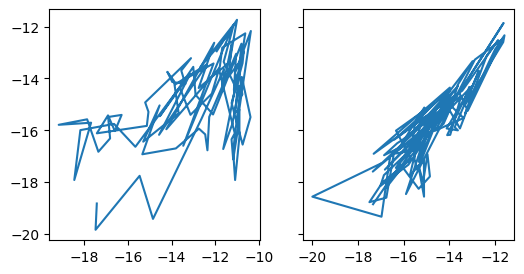

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(6,3))
ax1, ax2 = ax
ax1Y, ax1freq = fbank["normal"][0], fbank["normal"][1]
ax1.plot(ax1freq, ax1Y)
ax2Y, ax2freq = fbank["vfy"][0], fbank["vfy"][1]
ax2.plot(ax2freq, ax2Y)
plt.savefig("/content/drive/MyDrive/final_project/second_draft/plot/fft");

In [23]:
def plot_mfccs(mfccs):
    fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False,
                             sharey=True, figsize=(20,5))
    fig.suptitle('Mel Frequency Cepstrum Coefficients', size=16)
    i = 0
    for y in range(2):
        axes[y].set_title(list(mfccs.keys())[i])
        axes[y].imshow(list(mfccs.values())[i],
                    cmap='hot', interpolation='nearest')
        axes[y].get_xaxis().set_visible(False)
        axes[y].get_yaxis().set_visible(False)
        i += 1

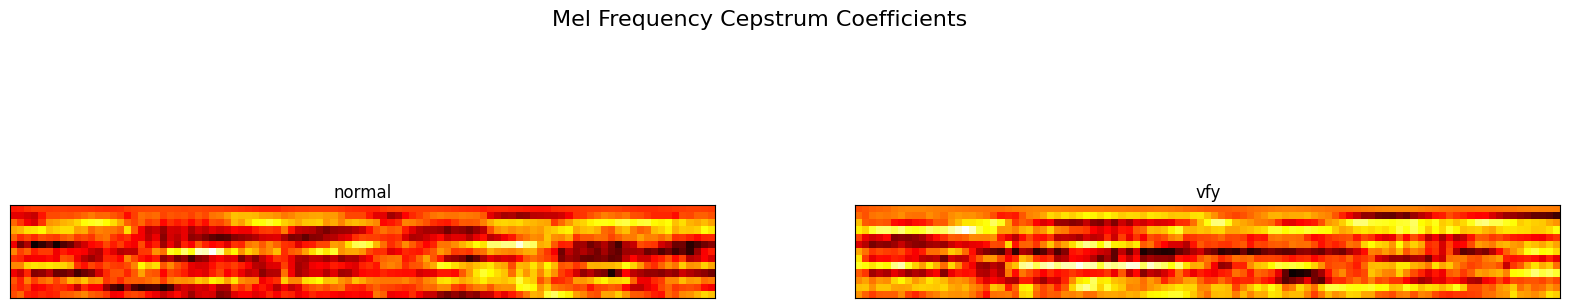

In [24]:
plot_mfccs(mfccs)
plt.show()